## Bank Customer Churn Prediction Dataset Exploratory Data Analysis

#### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

#### Load dataset

In [17]:
df = pd.read_csv(r"E:\MLP\Algorithms\supervised\Adaboost\data\raw\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [19]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [20]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 14


#### statestical Summary

In [21]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#### Drop unnecessary column form the dataset

In [22]:
df = df.drop(["RowNumber","CustomerId","Surname"], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Target Variable Distribution

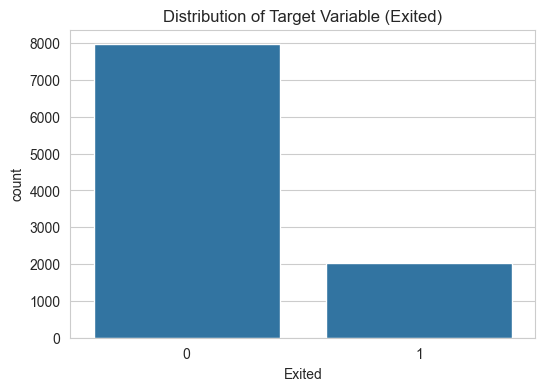

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Distribution of Target Variable (Exited)")
plt.show()

#### Gender vs churm

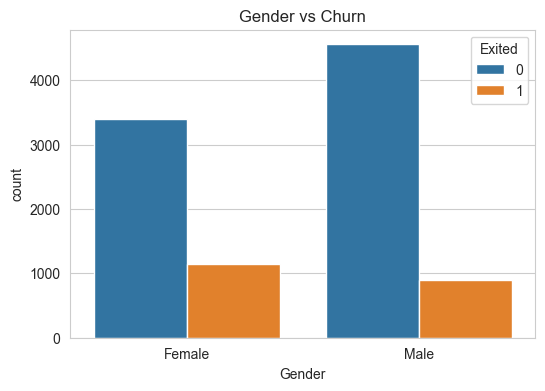

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Churn")
plt.show()

#### Geography vs churn

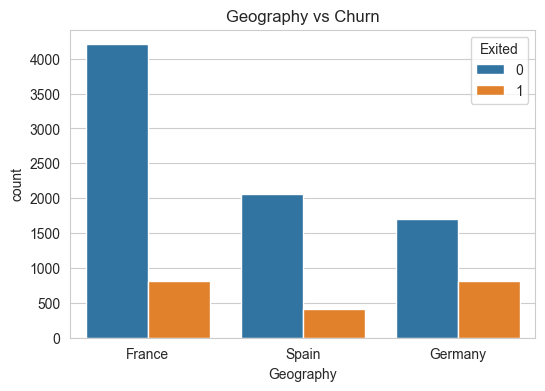

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Geography vs Churn")
plt.show()

#### Age distribution

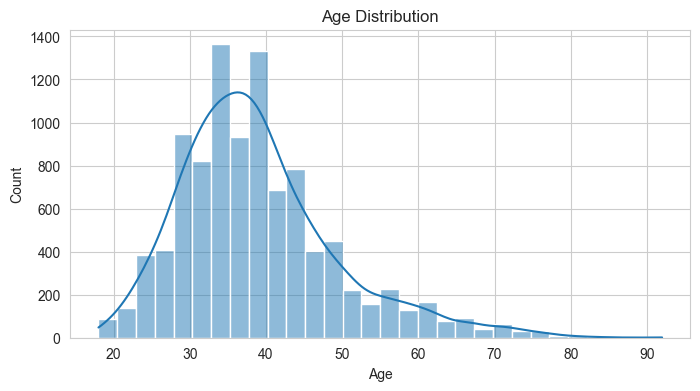

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(data= df, x="Age", bins = 30 ,kde =True)
plt.title("Age Distribution")
plt.show()

#### Age vs churn

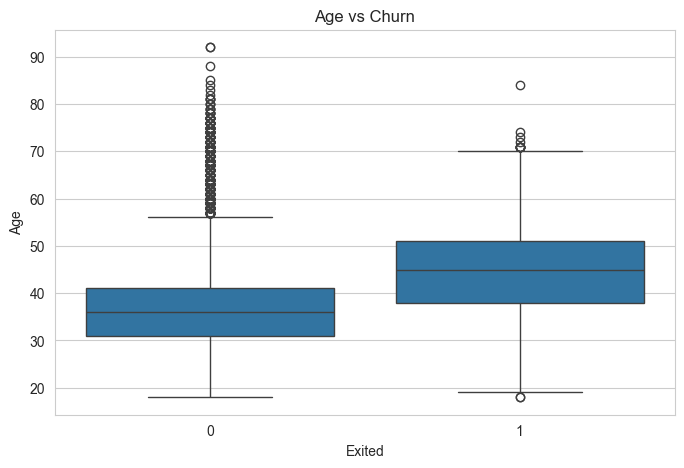

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age vs Churn")

plt.show()

#### Balance Distribution

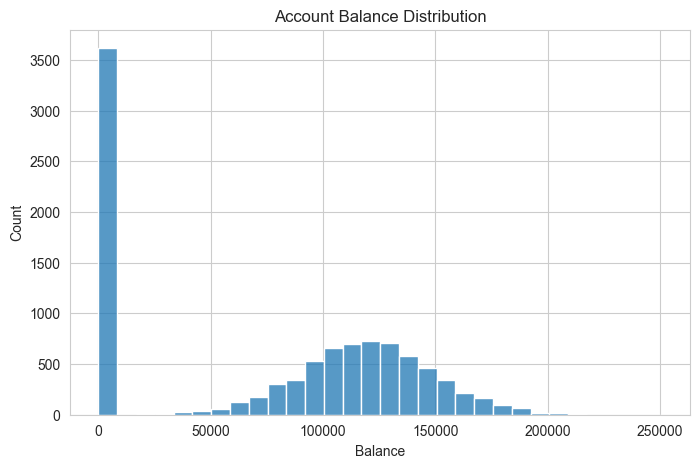

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["Balance"], bins=30)

plt.title("Account Balance Distribution")

plt.show()

#### Balance vs churn

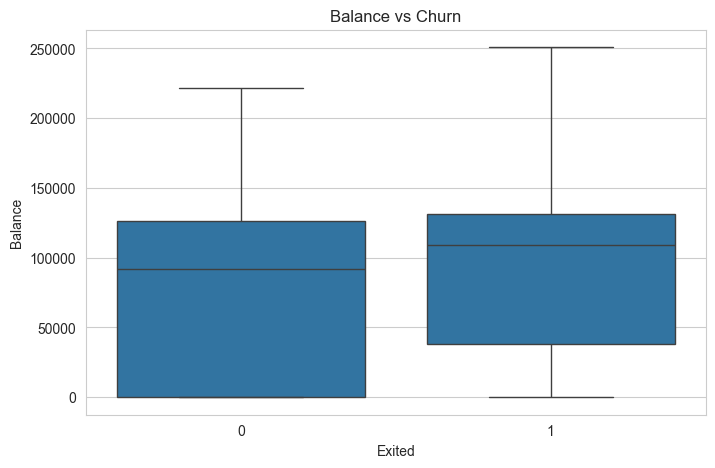

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Churn")

plt.show()


#### Creadit score distribution

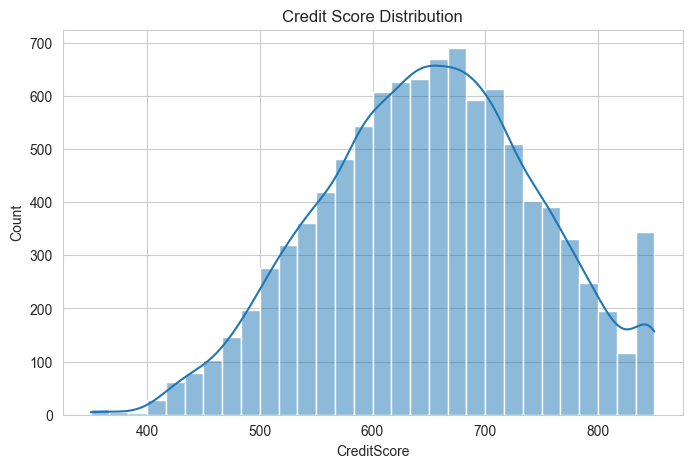

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["CreditScore"], bins=30, kde=True)

plt.title("Credit Score Distribution")

plt.show()

#### Tenure vs churn

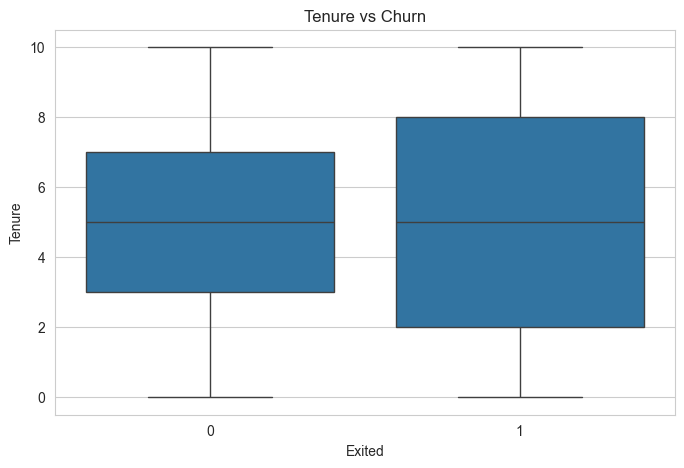

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Exited", y="Tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

#### Number of product vs churn

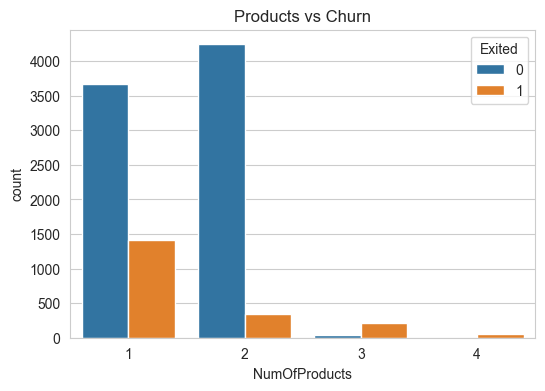

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x="NumOfProducts", hue="Exited", data=df)

plt.title("Products vs Churn")

plt.show()

#### Active Member vs churn

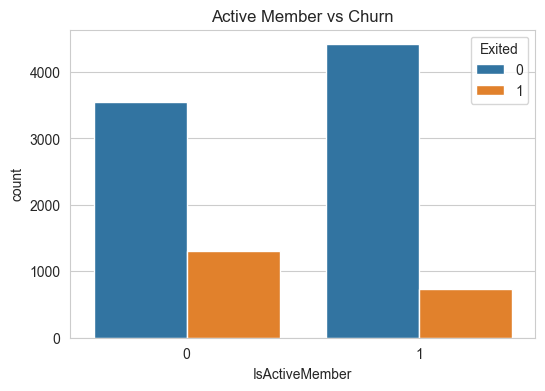

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x="IsActiveMember", hue="Exited", data=df)

plt.title("Active Member vs Churn")

plt.show()

Corelation Heatmap

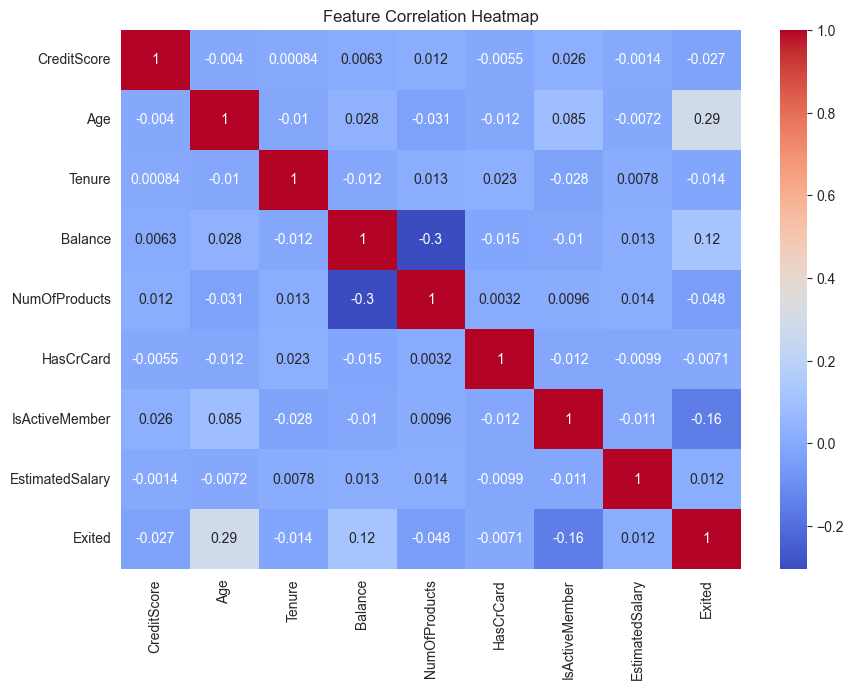

In [37]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

Pairplot

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


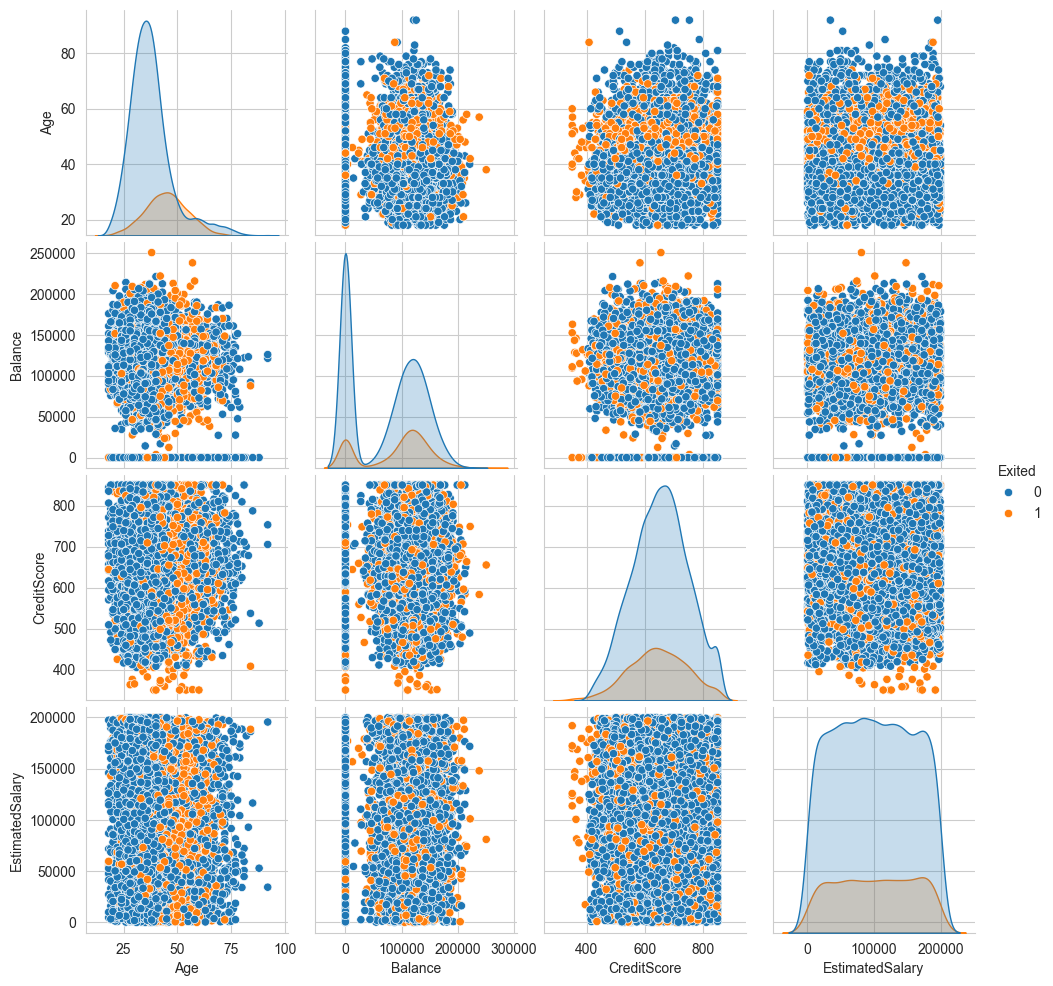

In [38]:
sns.pairplot(
    df[["Age","Balance","CreditScore","EstimatedSalary","Exited"]],
    hue="Exited"
)

plt.show()

In [39]:
churn_rate = df["Exited"].value_counts(normalize=True) * 100

print(churn_rate)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
